In [12]:
import os
N_cores = 1
os.environ["OMP_NUM_THREADS"] = str(N_cores)        # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = str(N_cores)   # export OPENBLAS_NUM_THREADS=4
os.environ["MKL_NUM_THREADS"] = str(N_cores)        # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_cores) # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = str(N_cores)    # export NUMEXPR_NUM_THREADS=6

import numpy as np
import matplotlib.pyplot as plt

import sys

#from ham_creation import create_hex_ham
from lat_creation import get_positions_graphene
from core import DOS_sparse, frequency_analysis, load_data
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
# Benchmarking
from time import time
from datetime import timedelta

hbar = 0.6582


# Matplotlib stuff
plt.rcParams.update({'font.size': 11})  # Match REVTeX default 10pt
plt.rcParams['pdf.fonttype'] = 42  # Save text as TrueType (editable) instead of paths
plt.rcParams['ps.fonttype'] = 42   # Same for PostScript
plt.rcParams['text.usetex'] = True  # Keep LaTeX rendering
plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams.update({
    'font.size': 11,              # Tamaño base general (afecta a textos libres)
    'figure.titlesize': 18,       # Título principal de la figura (suptitle)
    'axes.titlesize': 12,         # Título de cada gráfico (title)
    'axes.labelsize': 12,         # Etiquetas de los ejes (xlabel e ylabel)
    'xtick.labelsize': 11,        # Números/marcas del eje X
    'ytick.labelsize': 11,        # Números/marcas del eje Y
    'legend.fontsize': 11,        # Texto de los elementos de la leyenda
    'legend.title_fontsize': 11   # Título de la leyenda
})

# Configuración exclusiva para grosores y tamaños de elementos visuales
plt.rcParams.update({
    # 1. Líneas y Marcadores (El contenido de tus gráficos)
    'lines.linewidth': 3,          # Grosor de las líneas de los gráficos
    'lines.markersize': 10,           # Tamaño de los puntos/marcadores
    'lines.markeredgewidth': 1.5,    # Grosor del borde de los marcadores

    # 2. Gráficos de barras y formas (Patches)
    #'patch.linewidth': 1.2,          # Grosor del borde de las barras (plt.bar) o rectángulos

    # 3. El marco del gráfico (Ejes / Spines)
    #'axes.linewidth': 1.5,           # Grosor de la línea del recuadro exterior del gráfico

    # 4. La cuadrícula (Grid)
    'grid.linewidth': 0.8,           # Grosor de las líneas de la cuadrícula de fondo

    # 5. Las pequeñas marcas de los ejes (Ticks)
    'xtick.major.size': 6,           # Qué tan largas son las marcas del eje X
    'xtick.major.width': 1.5,        # Qué tan gordas son las marcas del eje X
    'ytick.major.size': 6,           # Qué tan largas son las marcas del eje Y
    'ytick.major.width': 1.5         # Qué tan gordas son las marcas del eje Y
})
path = "D:\\Downloads"

In [13]:
# ------------------------------------------------------------------------------
#### PARAMETERS OF THE MODEL
## PHYSICAL
# Type of light               
modifier_id = 'circln'
# Hamiltonian type
type_ham = 'basic'
# Parameters of the ham (only read if hbn)
ham_params = 0.5
# Energy in pulse                        
E = 0.5
# Temperature                       
Temp = 1e-9
# Chemical potential
mu = 0.01
# Intensity param     (no units)
gamma = 0.015

## SIMULATION
# Size of hamiltonian (2**N_pot)
N_pot = 19
N = 2**N_pot
# Amount of periods to be simulated
n_periods = 500
# Simulation steps per period
steps_per_T = 1000
# Amount of measures per period
meas_per_T = 16
N_measures = meas_per_T*n_periods
# Amount of random vectors used in calculation
N_random_vector = 5
# Momenta
M = int(np.sqrt(N))
#M = 362

## RESULT ANALYSIS
# Range of searching the maximim frequency (in period^-1 units)
range_search = 1


In [14]:
## CALCULATED PARAMS
# ------------------------------------------------------------------------------
####  Defining a hamiltonian (own)



# Parameters of the laser
w = E/hbar
T = 2*np.pi/w    
t_vec = np.linspace(0,n_periods*T , steps_per_T*n_periods)   
# Amount of half multiples of E where the occupation is obtained
hE_reps = 2
# Broadening in the energies
broad = 8.5*np.pi/M
t_vec_measures = np.linspace(0, n_periods*T, N_measures)

# Print of parameters to check results
print('PARAMETERS OF CALCULATION')
print(f'Type of hamiltonian is {type_ham}')
print(f'Hamiltonian parameter is {ham_params}')
print(f'Type of light is {modifier_id}')
print(f'# of atoms: {N}')
print(f'# of moments: {M}')
print(f'Energy: {E} eV')
print(f'Intensity param: {gamma}')
print(f'Temperature: {Temp} K')
print(f'Chem potential: {mu} eV')
print(f'# of Random Vectors: {N_random_vector}')
print(f'# of periods: {n_periods}')
print(f'steps/period: {steps_per_T}')
print(f'# measures/T: {meas_per_T}')


# Names of file and info on graphs
fig_title_info = f'$N={{{2**N_pot}}}$, $\\hbar\\omega={E}$ eV, T={Temp} K, $\\mu$={mu} eV, $\\Gamma$={gamma}, M={M}\n'
extra_text = f'Light: {modifier_id}\n$\\delta E={broad:.3f}$\n# Rand Vecs: {N_random_vector}\nMeasures/T={meas_per_T}\nSteps/T={steps_per_T}'

#fig_title_info=f'Light: {modifier_id},$N={{{2**N_pot}}}$, $\\hbar\\omega={E}$ eV, T={Temp} K, $\\mu$={mu} eV, $\\Gamma$={gamma}\n$M={M}$, $R={N_random_vector}$, Meas/T={meas_per_T}, $St/T={steps_per_T}$'

EF_list, n_E_list, dos_list, dosn_list = load_data(modifier_id, N_pot, E, Temp, mu, gamma, 
                        M, N_random_vector, n_periods, meas_per_T, steps_per_T, type_ham, ham_params, R=None, out_file_loc=path)
            
# Remaking the graphs of oscillations in time
hE_list = [hE*E/2 for hE in range(-hE_reps, hE_reps+1)]


PARAMETERS OF CALCULATION
Type of hamiltonian is basic
Hamiltonian parameter is 0.5
Type of light is circln
# of atoms: 524288
# of moments: 724
Energy: 0.5 eV
Intensity param: 0.015
Temperature: 1e-09 K
Chem potential: 0.01 eV
# of Random Vectors: 5
# of periods: 500
steps/period: 1000
# measures/T: 16


FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'D:\\Downloads/Out/circln/G=0.015_E=0.5_Temp=1e-09_mu=0.01/N=19_M=724_R=5_nT=500_measT=16_stT=1000/Ene_R'

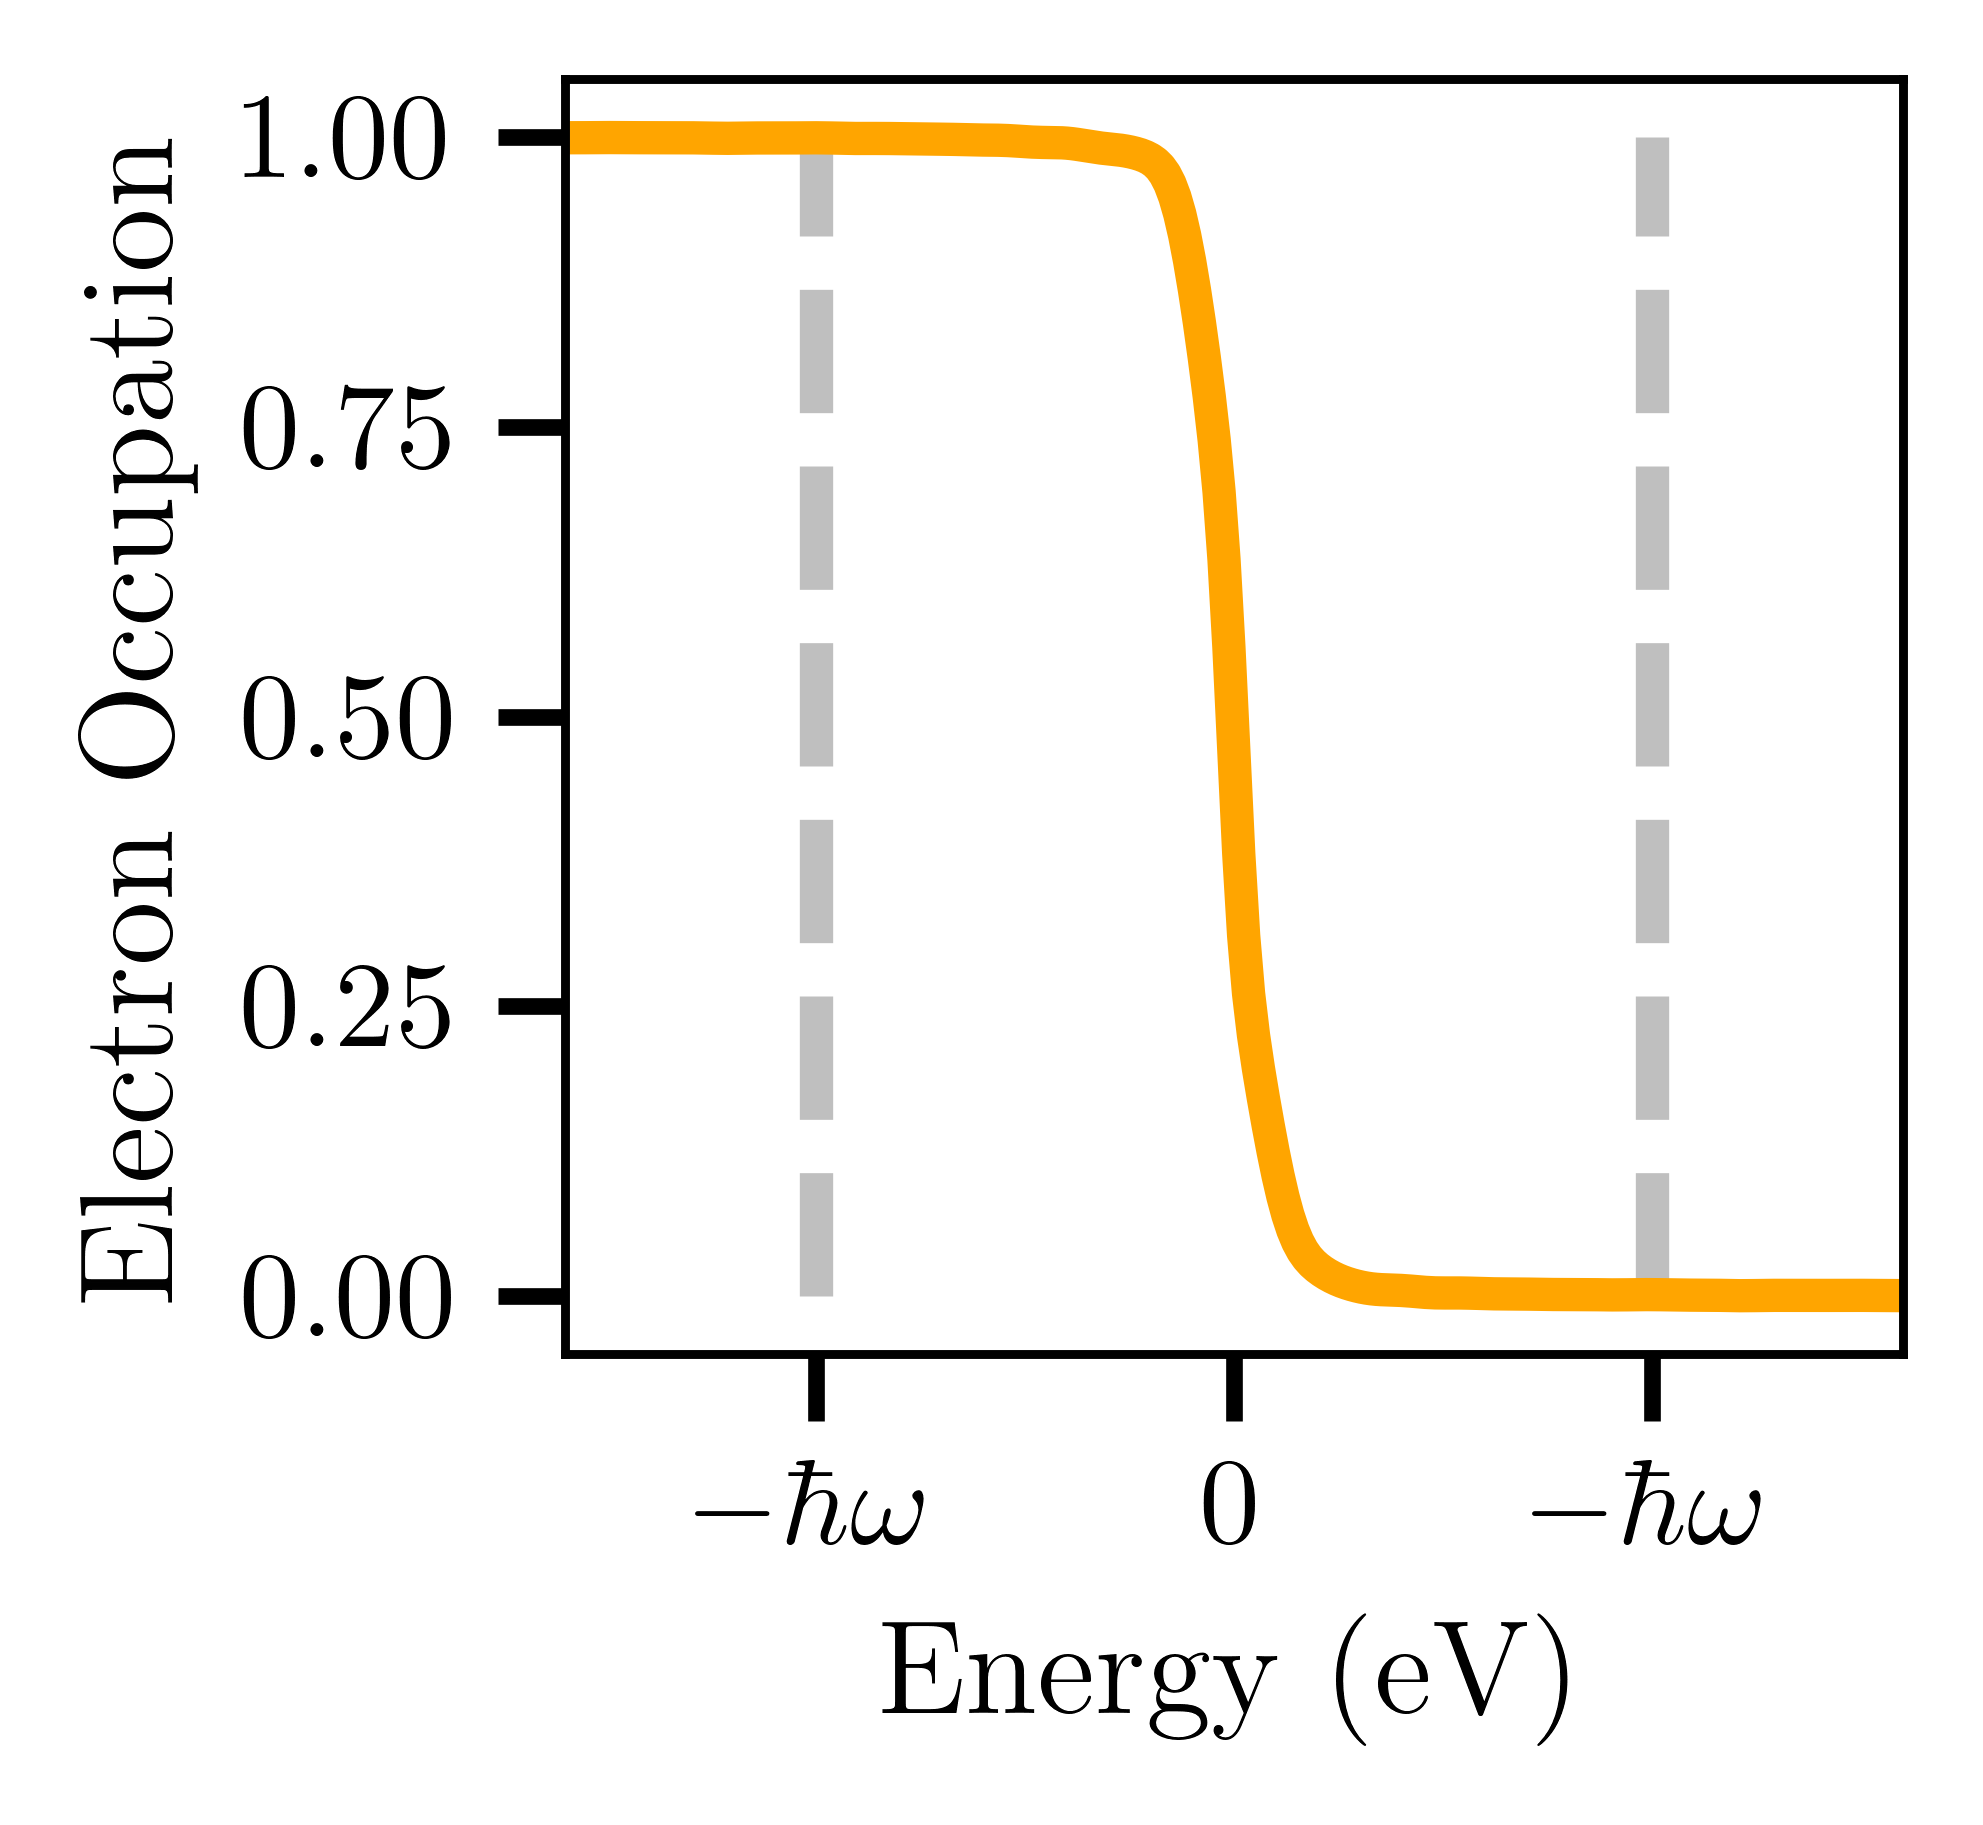

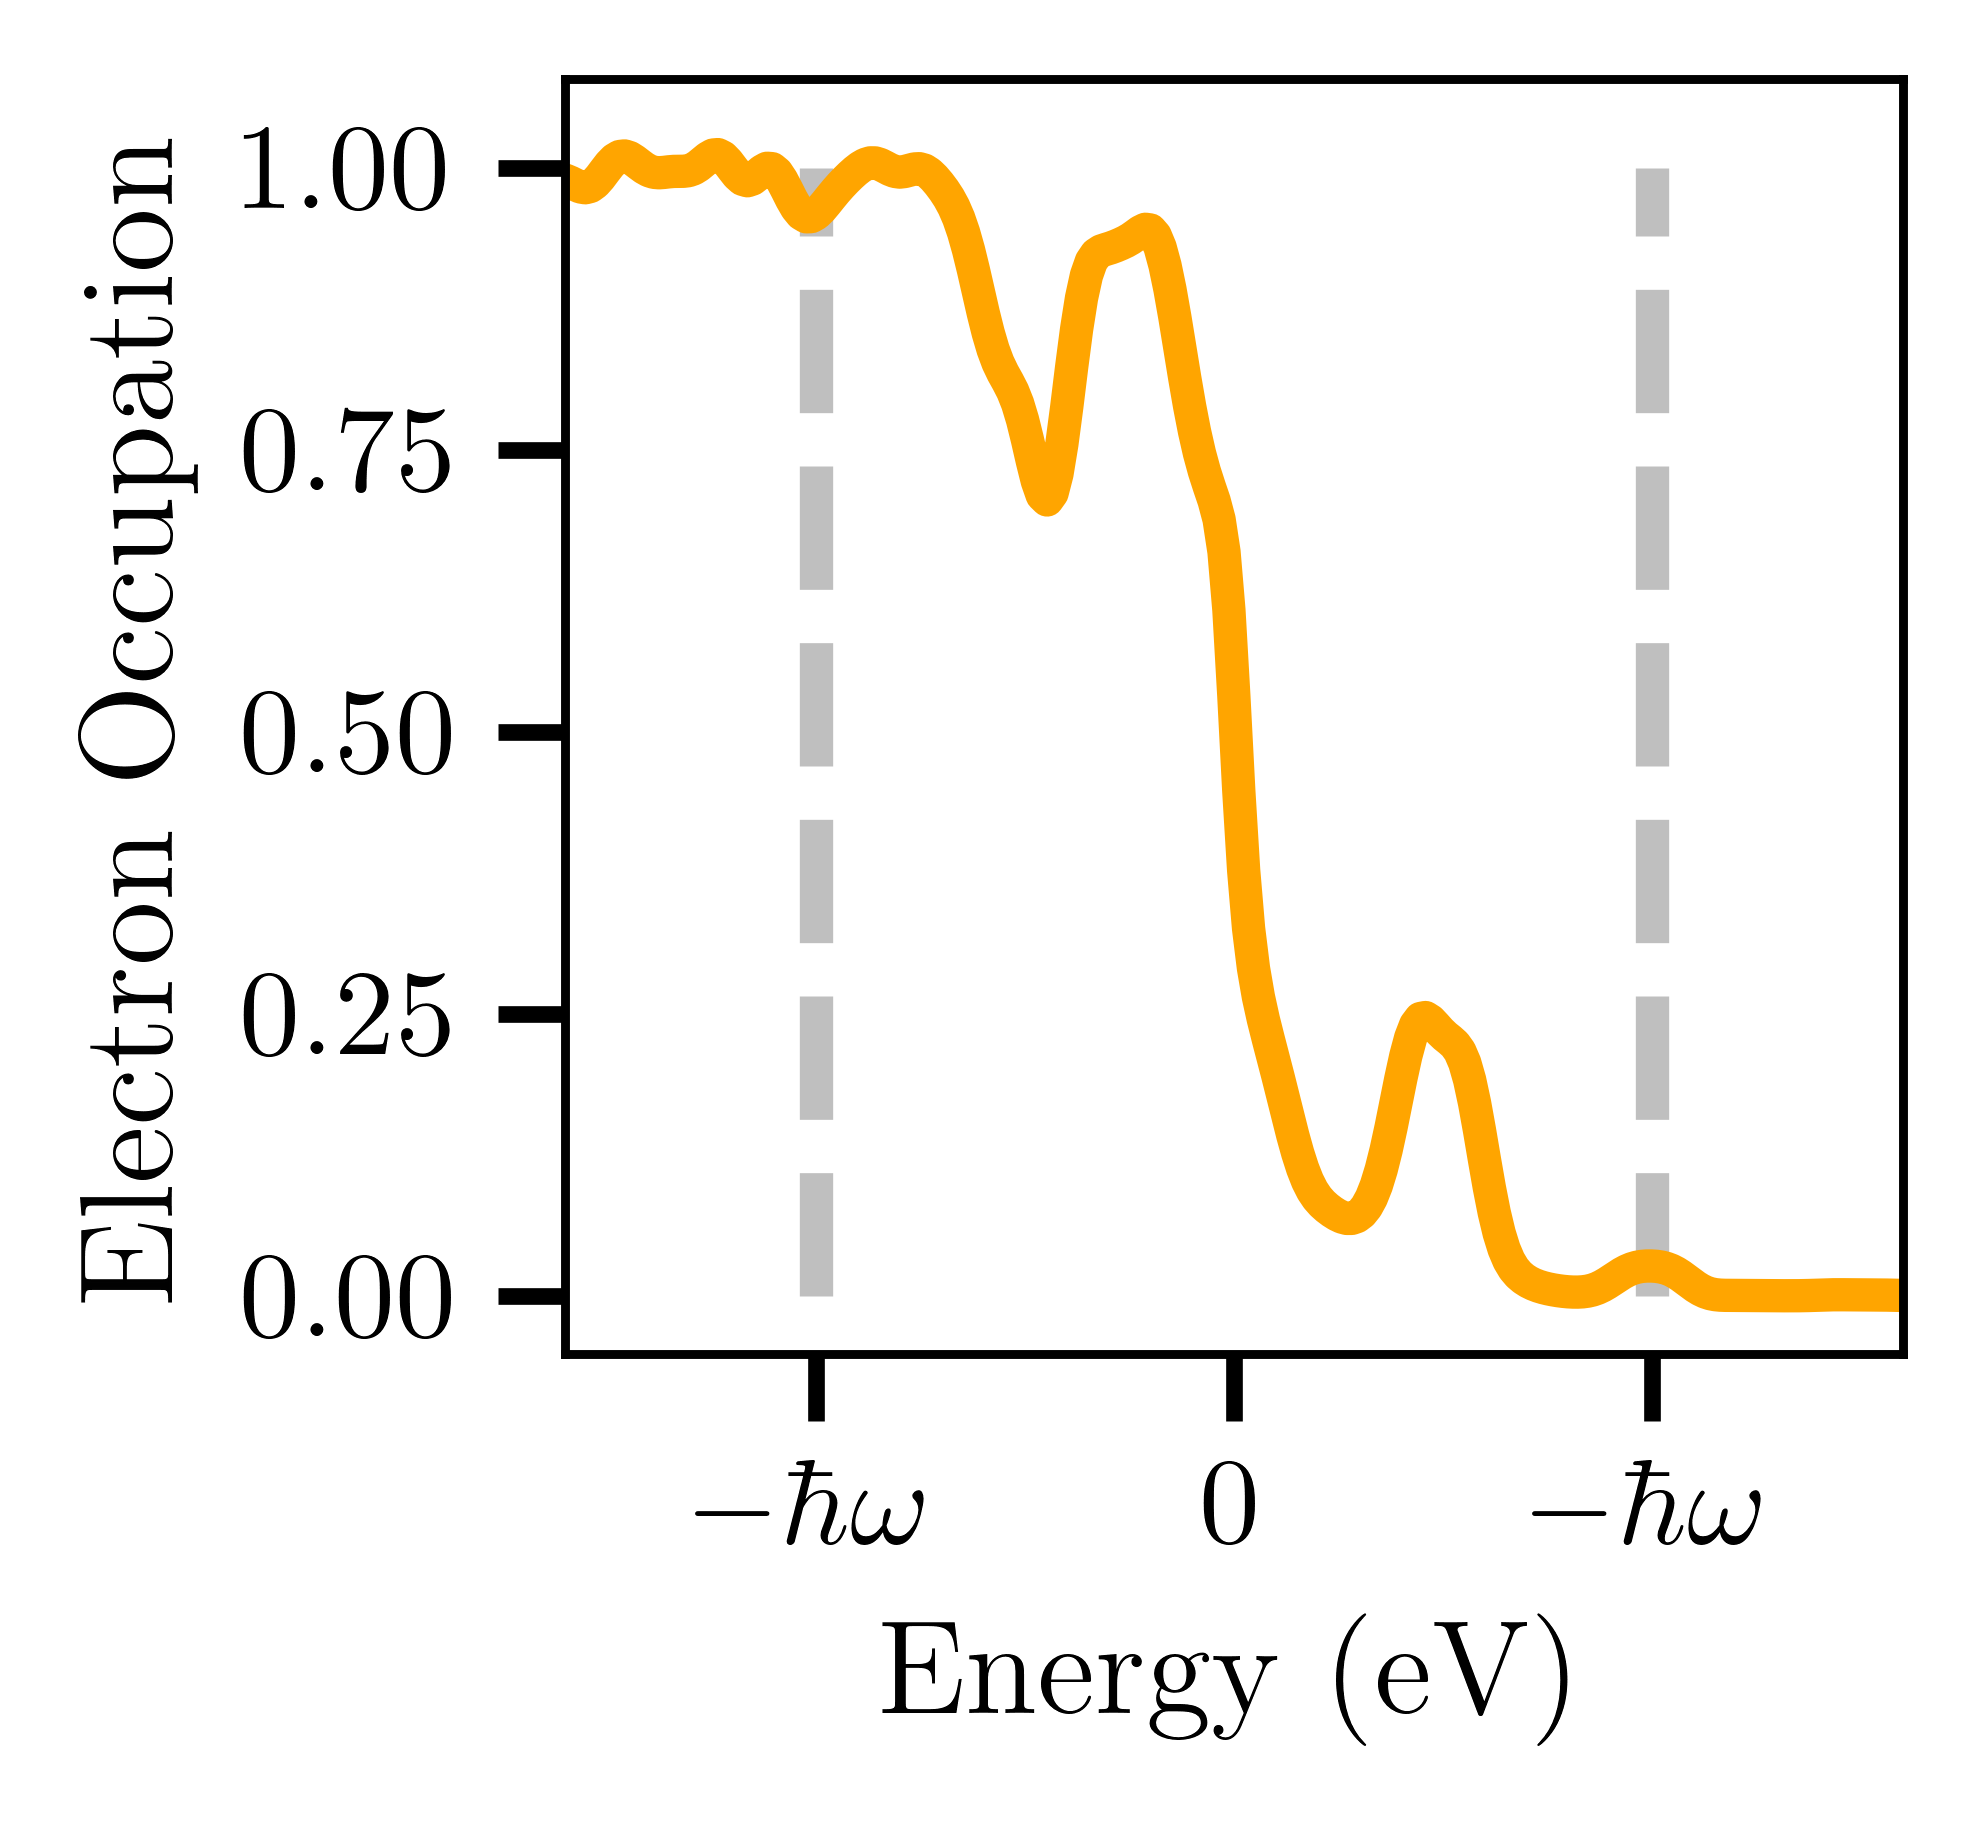

In [ ]:
# TWO TIMES FOR THE COMPARISON GRAPH
min_e, max_e = -1.6*E, 1.6*E
hw_lines_step = 1.0*E
hw_hlines = [i for i in [hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]
hw_hlines += [i for i in [-hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]
for i in [0, -5]:
    fig, ax = plt.subplots(dpi=800, figsize=(6/2.54, 5.5/2.54), layout='constrained')
    ax.plot(EF_list[i,:], n_E_list[i,:], color='orange', label=f't={round(t_vec_measures[i]/T, 3)}T')
    #ax.legend()
    #cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('Electron Occupation')
    ax.set_xlim(min_e, max_e)
    ax.vlines(hw_hlines, 0, 1, color='grey', ls='--', alpha=0.5, zorder=1)
    #ax.set_xticks([-E, -E/2, 0, E/2, E], labels=['$-\\hbar \\omega$', '$-\\hbar \\omega/2$', '$0$', '$\\hbar \\omega/2$', '$-\\hbar \\omega$'])
    ax.set_xticks([-E, 0, E], labels=['$-\\hbar \\omega$', '$0$', '$-\\hbar \\omega$'])
    #ax.text(min_e + 0.5*E, 0.2, extra_text, bbox=props)
    fig.savefig(f'Graphs/neq_show{i}.pdf')
    plt.show()

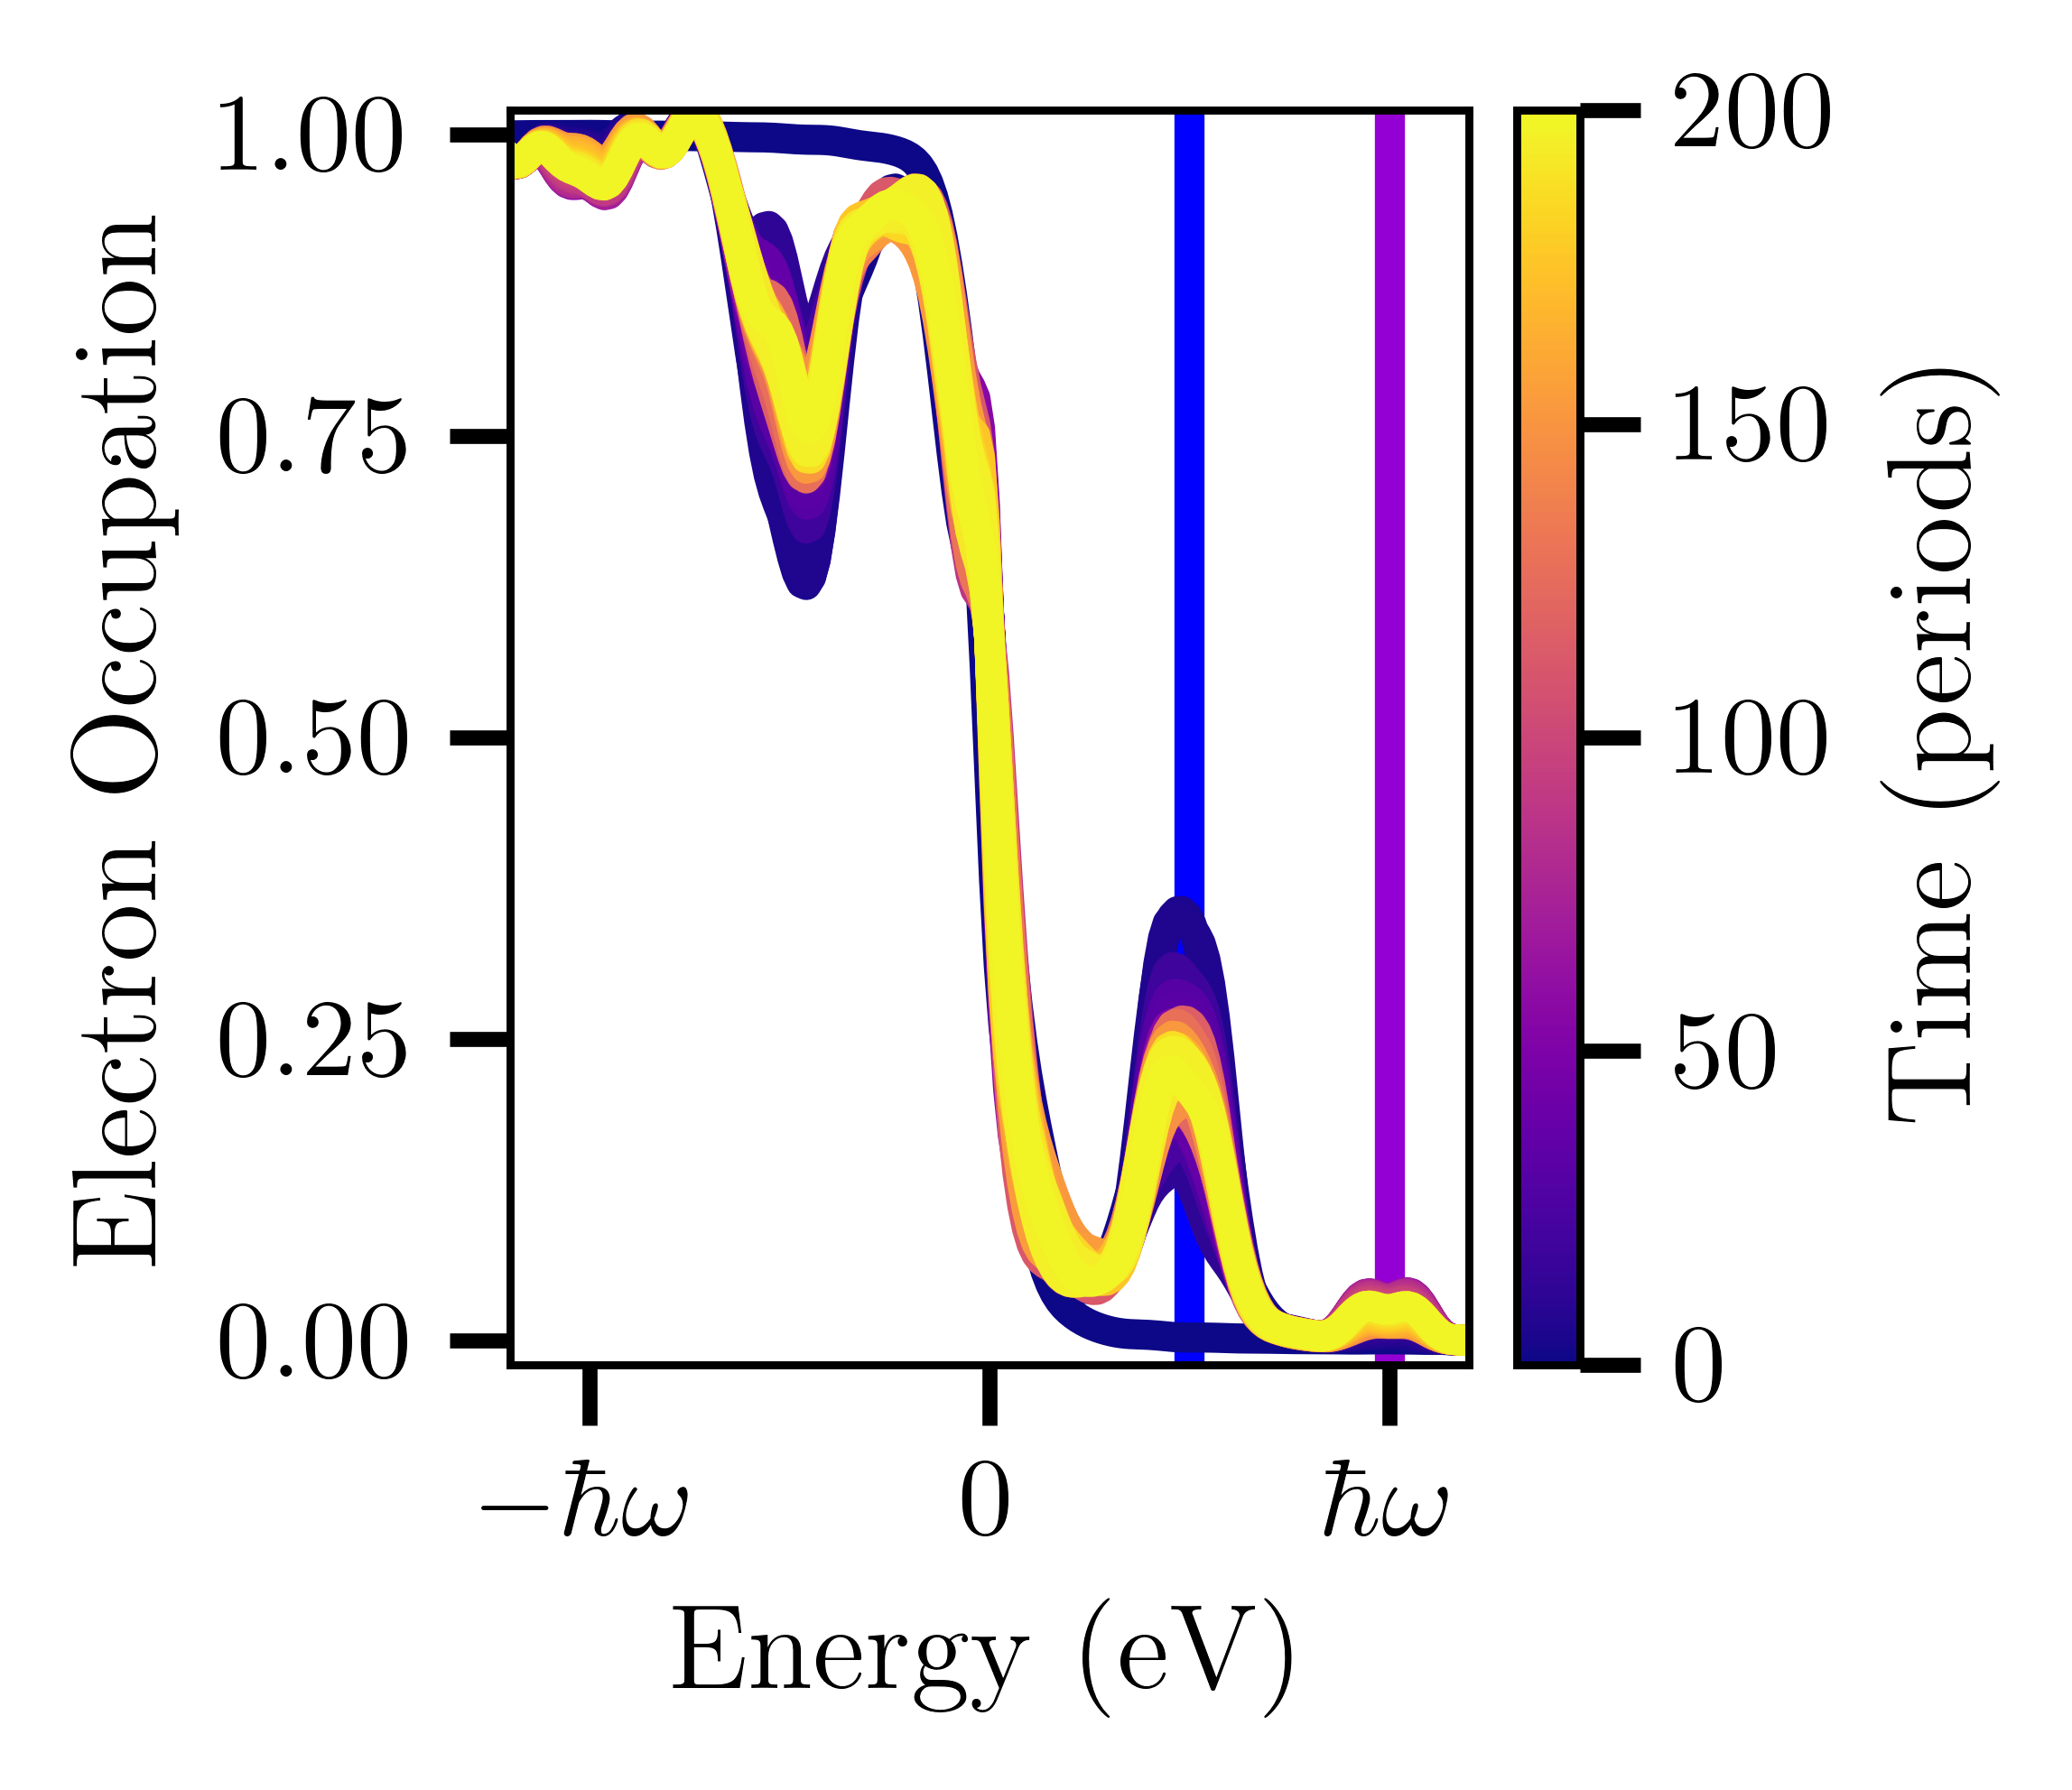

In [ ]:
# Energy window and time windows
step_repr_period = 0.5
max_period = 200
min_e, max_e = -1.2*E, 1.2*E


cmap = plt.cm.plasma 
norm = Normalize(vmin=t_vec.min()/T, vmax=max_period)
ylim = (-0.02, 1.02)
hw_lines_step = 0.5*E
hw_hlines = [i for i in [hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]
hw_hlines += [i for i in [-hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]
# ------------------------------------------------------------------------------
# Occupation (E)
# Text box
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
fig, ax = plt.subplots(dpi=800, figsize=(7/2.54, 6/2.54), layout='constrained')
for i in range(0, max_period*meas_per_T, int(16/step_repr_period)):
    ax.plot(EF_list[i,:], n_E_list[i,:], color=cmap(norm(t_vec_measures[i]/T)))
#ax.legend()
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Electron Occupation')
ax.set_xlim(min_e, max_e)
#ax.vlines(hw_hlines, 0, 1, color='grey', ls='--', alpha=0.5, zorder=1)
ax.vlines([E/2], ymin=ylim[0], ymax=ylim[1], color='blue', ls='-', zorder=1)
ax.vlines([E], ymin=ylim[0], ymax=ylim[1], color='darkviolet', ls='-', zorder=1)
ax.set_xticks([-E, 0, E], labels=['$-\\hbar \\omega$', '0', '$\\hbar \\omega$'])
ax.set_ylim(ylim)
fig.savefig('Graphs/neq_time.pdf')
#fig.suptitle(fig_title_info)
#ax.text(min_e + 0.5*E, 0.2, extra_text, bbox=props)



In [ ]:
# ------------------------------------------------------------------------------
# OCCUPATION (Time)
color_list = ['olivedrab', 'red', 'orange', 'blue', 'darkviolet']

occ_drop_list, fourier_occ, freq, char_freq, max_freq_ind = frequency_analysis(EF_list, n_E_list, hE_list, t_vec_measures, T, range_search)
fig, ax = plt.subplots(dpi=800, figsize=(7/2.54, 6/2.54), layout='constrained')
reescale = np.max(occ_drop_list[3]) / np.max(occ_drop_list[4]) / 2
ax.plot(np.array(t_vec_measures)/T, occ_drop_list[3], c='blue', ls='-', label=f"$\\varepsilon=\\hbar\\omega/2$")
ax.plot(np.array(t_vec_measures)/T, occ_drop_list[4]*reescale, c='darkviolet', ls='-', label=f"$\\varepsilon=\\hbar\\omega$")
#ax.plot(np.array(t_vec_measures)/T, occ_drop_list[1], c='cyan', ls='-', label=f"$\\varepsilon=-\\hbar\\omega/2$")
#ax.plot(np.array(t_vec_measures)/T, occ_drop_list[0], c='pink', ls='-', label=f"$\\varepsilon=-\\hbar\\omega$")
#ax.plot(np.array(t_vec_measures)/T, occ_drop_list[2], c='orange', marker='.', ls='--', label=f"E=0")
ax.set_xlabel('Time (Periods)')
ax.set_ylabel('Electron Occupation')
ax.set_xlim(0, 100)
#ax.set_title(fr'Occupation')
#fig.suptitle(fig_title_info)
fig.savefig('Graphs/neq_n(t).pdf')
ax.legend()


TypeError: frequency_analysis() takes 5 positional arguments but 6 were given

Text(0.5, 1.0, 'Density of States')

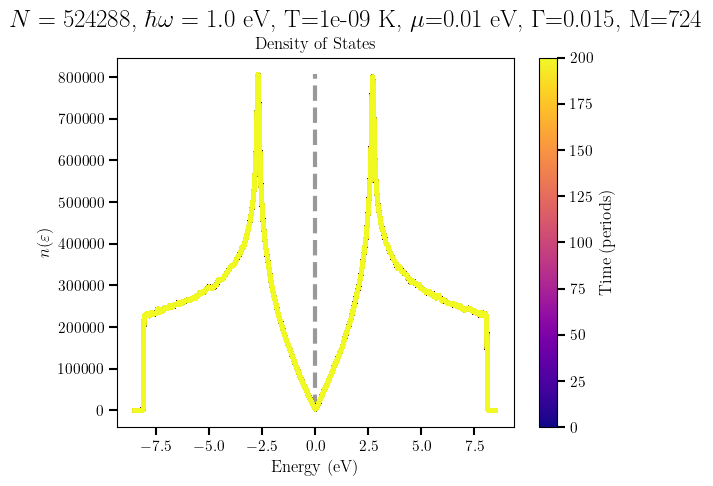

In [ ]:
# ------------------------------------------------------------------------------
# DOS (Energy)
fig, ax = plt.subplots()
for i in range(N_measures):
    ax.plot(EF_list[i,:], dos_list[i,:], color=cmap(norm(t_vec_measures[i])), label=f't={round(t_vec_measures[i]/T, 3)}T')
#ax.legend()
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('$n(\\varepsilon)$')
#ax.vlines(hw_hlines, 0, np.max(dos_list), color='grey', ls='--', alpha=0.5, zorder=1)
ax.vlines([0], 0, np.max(dos_list), color='grey', ls='--', alpha=0.8, zorder=1)
fig.suptitle(fig_title_info)
ax.set_title('Density of States')

Text(0.5, 1.0, 'Density of States')

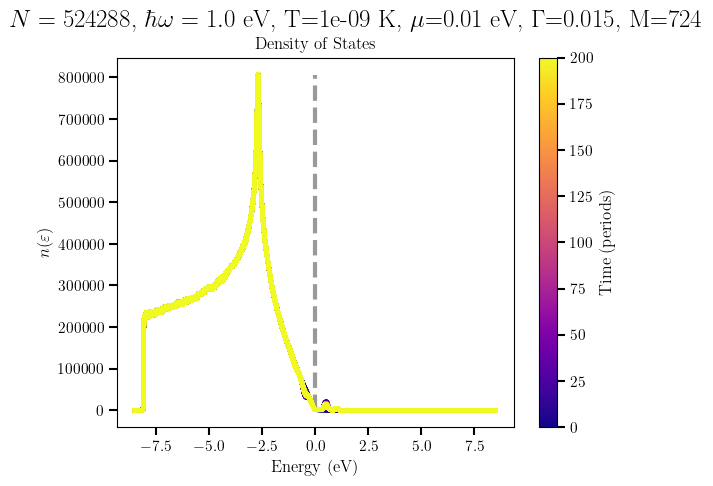

In [ ]:
# ------------------------------------------------------------------------------
# DOS*Occ (Energy)
fig, ax = plt.subplots()
for i in range(N_measures):
    ax.plot(EF_list[i,:], dosn_list[i,:], color=cmap(norm(t_vec_measures[i])), label=f't={round(t_vec_measures[i]/T, 3)}T')
#ax.legend()
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('$n(\\varepsilon)$')
#ax.vlines(hw_hlines, 0, np.max(dos_list), color='grey', ls='--', alpha=0.5, zorder=1)
ax.vlines([0], 0, np.max(dos_list), color='grey', ls='--', alpha=0.8, zorder=1)
fig.suptitle(fig_title_info)
ax.set_title('Density of States')


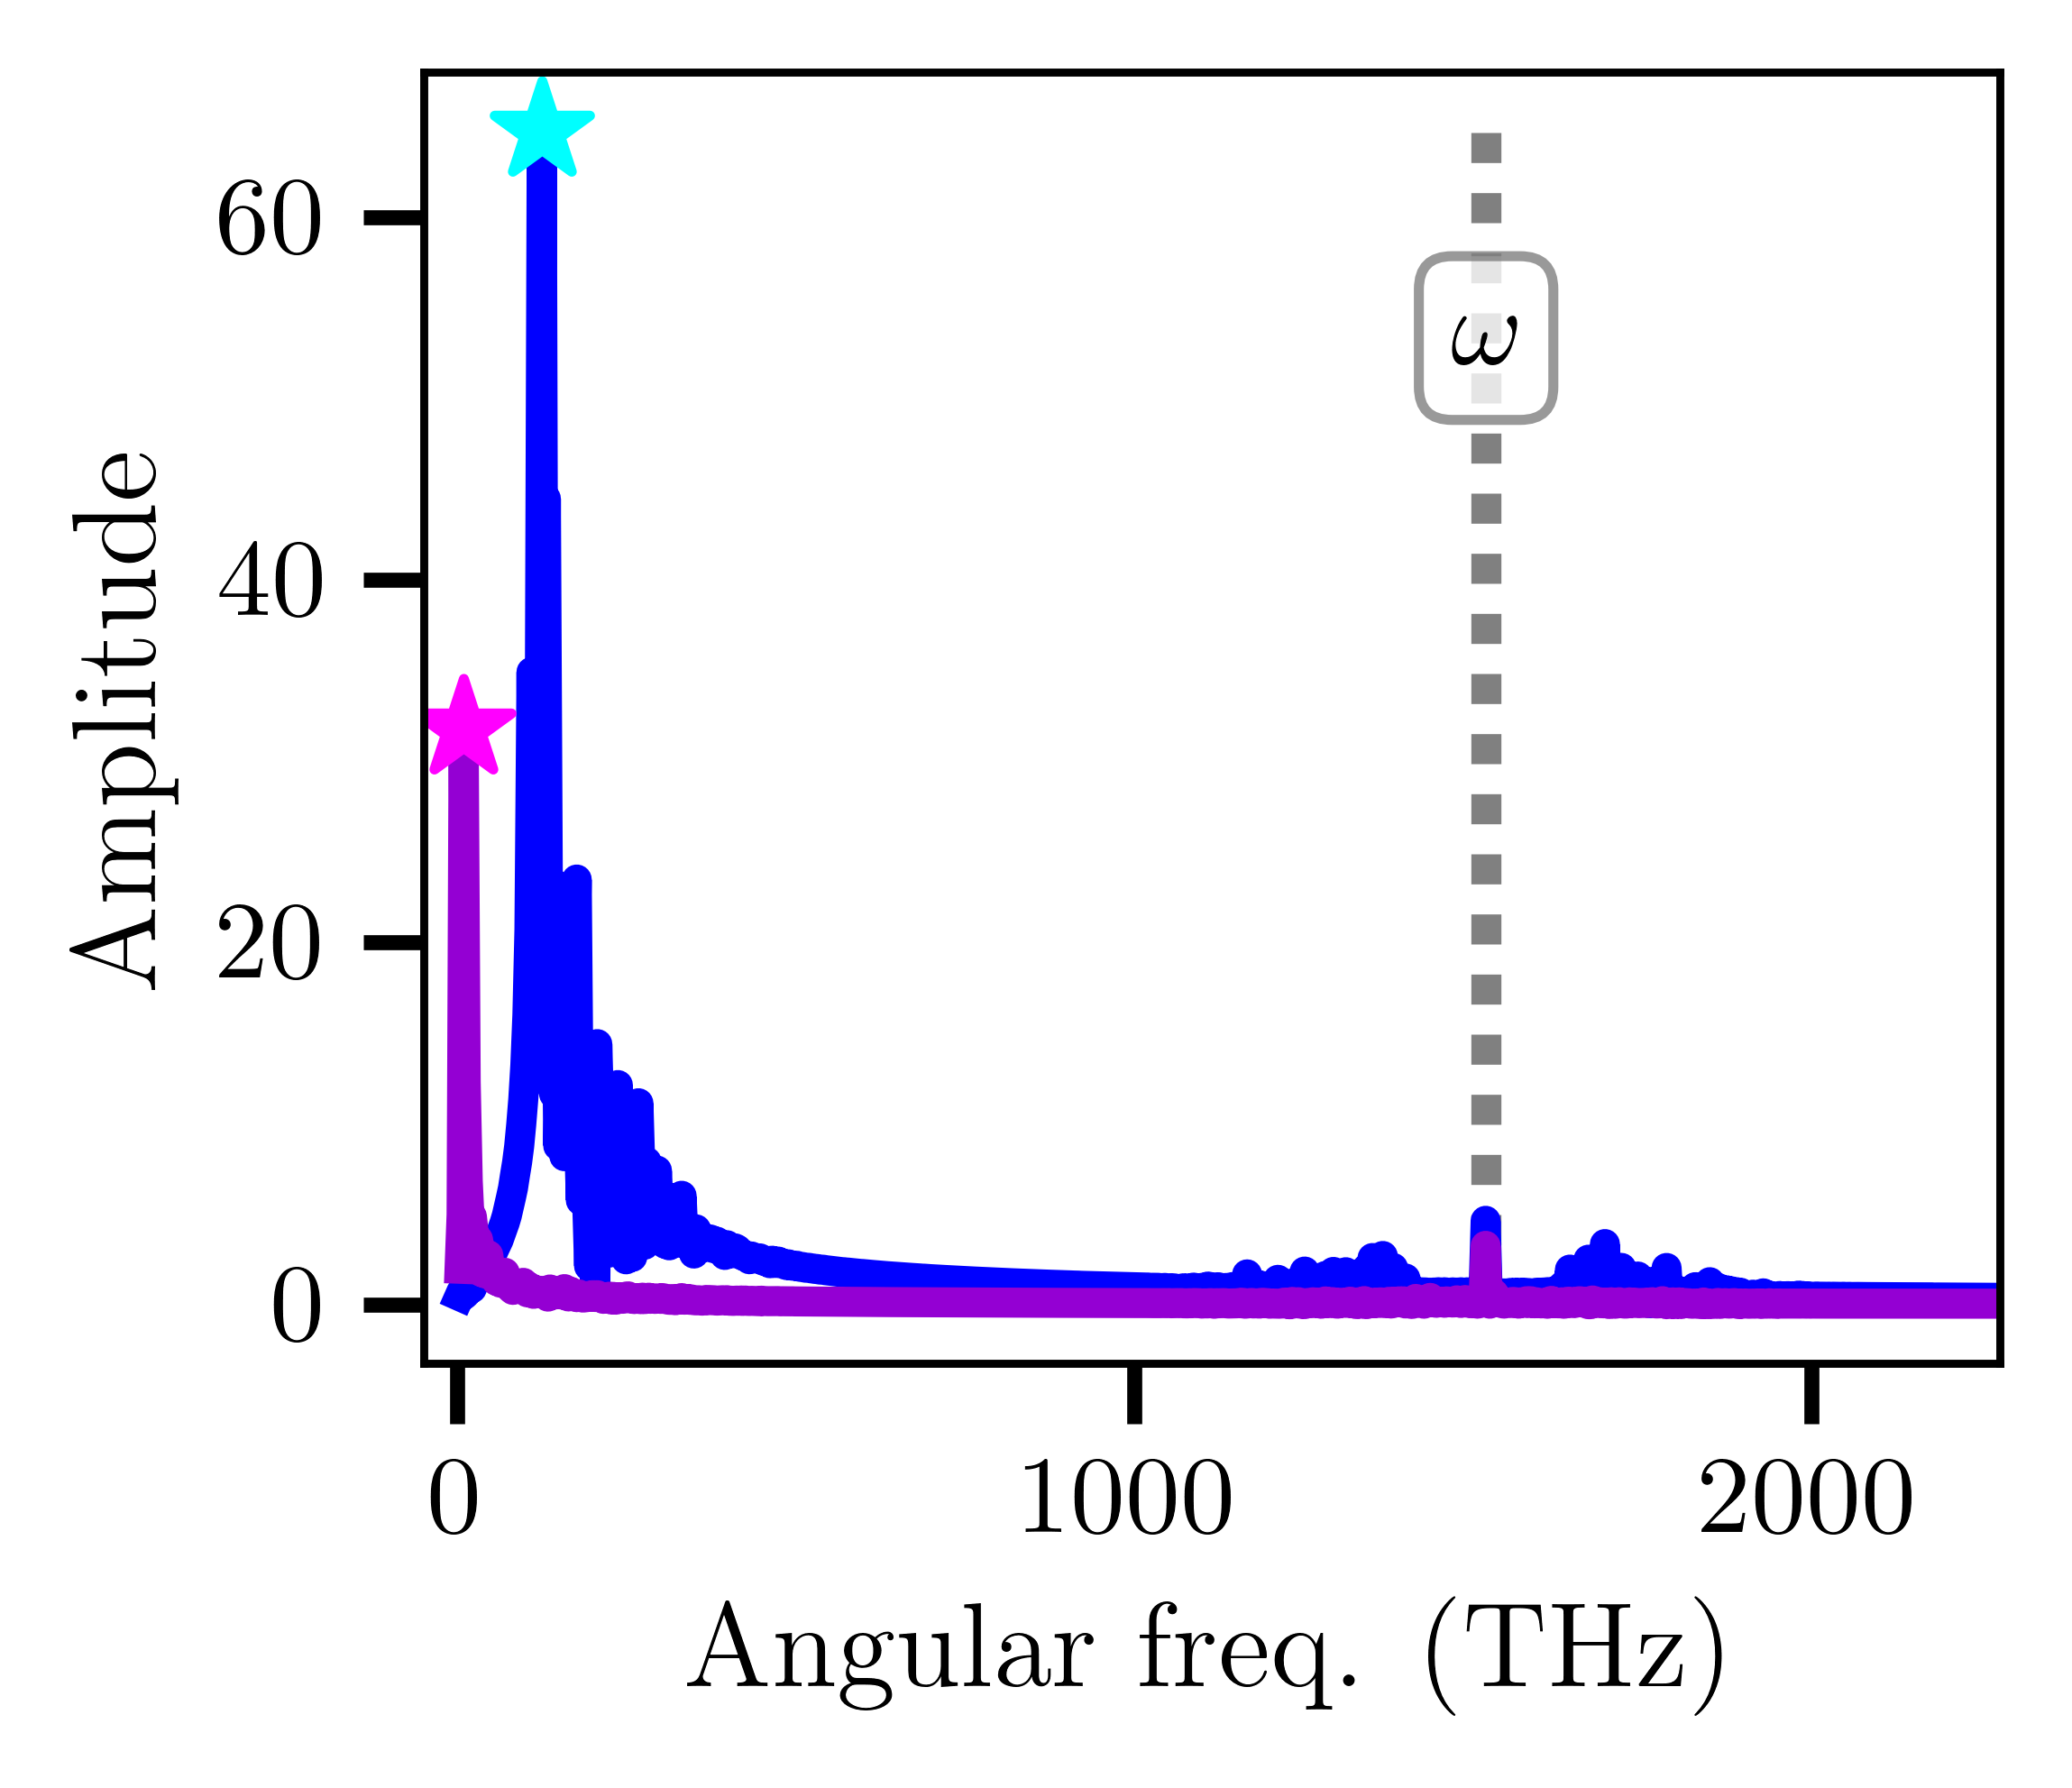

In [ ]:
max_w = 1.5
freq_graph = freq * 1000
max_freq = min(max_w*w*1000, freq_graph[-1]*T/(2*np.pi))
props = dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.8)

fig, ax = plt.subplots(dpi=800, figsize=(7/2.54, 6/2.54), layout='constrained')

#ax.plot(freq*T/(2*np.pi), fourier_occ[2], c='orange', marker='.', ls='--', label=f'$E = 0\\hbar\\omega$')
ax.plot(freq_graph, fourier_occ[3], c='blue', ls='-', label=f'$E = 0.5\\hbar\\omega$')
ax.plot(freq_graph, fourier_occ[4], c='darkviolet', ls='-', label=f'$E = 1\\hbar\\omega$')
# Markers of max frequencies
#ax.scatter(freq[max_freq_ind[2]], fourier_occ[2, max_freq_ind[2]], color='red', marker='*', zorder=2)
ax.scatter(freq_graph[max_freq_ind[3]], fourier_occ[3, max_freq_ind[3]], color='cyan',
           marker='*', zorder=2)
ax.scatter(freq_graph[max_freq_ind[4]], fourier_occ[4, max_freq_ind[4]], color='magenta',
           marker='*', zorder=2)
ax.set_xlim(-0.05*1000, max_freq)
ax.vlines(1000*np.arange(w, max_w*w, w), 0, np.max(fourier_occ[3]), ls=(0, (1, 1)), color='gray', zorder=1)
ax.text((w-0.05)*1000, np.max(fourier_occ[3])*0.8, '$\\omega$', bbox=props)
#ax.text(2*w-0.3, 80, '$\\omega=2\\omega_p$', bbox=props)
#wc_text = f'$\\omega_c = {char_freq[2]:.6f}$ fs$^{{-1}}$\n$\\omega_c = {char_freq[3]:.6f}$ fs$^{{-1}}$\n$\\omega_c = {char_freq[4]:.6f}$ fs$^{{-1}}$'
#ax.text(0.72, 0.98, wc_text, transform=ax.transAxes, verticalalignment='top', bbox=props)
#ax.legend(loc=(0.47, 0.7815), labelspacing=0.8, edgecolor='grey')
ax.set_xlabel('Angular freq. (THz)')
ax.set_ylabel('Amplitude')
fig.savefig('Graphs/neq_fourier.pdf')